# Müşteri Churn Tahmini — Uçtan Uca Pipeline

Bu notebook, bir telekom şirketinin müşteri churn (kayıp) davranışını tahmin etmek için
geliştirilmiş uçtan uca bir makine öğrenmesi pipeline'ı sunuyor. Halka açık **IBM Telco
Customer Churn** (Kaggle) veri seti kullanılarak Python / scikit-learn ekosistemiyle
geliştirildi.

**Kullanılan metodoloji:**
- İstatistiksel EDA (Cramér's V, point-biserial korelasyon, multicollinearity)
- Tek-kolon ablation ile leakage tespiti
- Train-only SMOTE (CV-leakage'siz, imbalanced-learn Pipeline ile)
- Genetik algoritma ile feature selection (F1 objective)
- Dört modelin (GradientBoosting, RandomForest, XGBoost, CatBoost) paralel hyperparameter
  tuning ve karşılaştırması
- Threshold tuning (recall/precision trade-off analizi)


In [1]:
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loading import load_clean, TARGET_COL, ID_COL
from src import eda, preprocessing as pp, leakage, feature_selection as fs
from src import modeling as md, evaluation as ev
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 50)


## 1) Veri Yükleme ve Temizlik

Telco Customer Churn veri setinin bilinen bir kalite sorunu var: `TotalCharges` sayısal bir
kolon olmasına rağmen CSV'de string olarak saklanıyor ve `tenure=0` olan (henüz ilk faturasını
almamış) 11 yeni müşteri için boşluk karakteri içeriyor. Bunu satır silmeden, mantıklı bir
değerle (burada 0) doldurarak çözüyoruz.


In [2]:
df = load_clean()
print("Şekil:", df.shape)
print("\nChurn dağılımı:")
print(df[TARGET_COL].value_counts(normalize=True).rename("oran"))
df.head()


Şekil: (7043, 21)

Churn dağılımı:
Churn
0    0.73463
1    0.26537
Name: oran, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2) Keşifsel Veri Analizi (EDA)

EDA zinciri: missing/constant filtreleme → cardinality → target association →
multicollinearity.


In [3]:
num_cols_raw = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols_raw = [c for c in df.columns if c not in num_cols_raw + [TARGET_COL, ID_COL]]

mc_report = eda.missing_constant_report(df)
print("Missing/constant filtresine takılan kolon sayısı:",
      (mc_report["drop_missing"] | mc_report["drop_constant"]).sum())
mc_report.head()


Missing/constant filtresine takılan kolon sayısı: 1


,missing_ratio,top_value_ratio,drop_missing,drop_constant
column,,,,
customerID,0.0,0.000142,False,False
gender,0.0,0.504756,False,False
SeniorCitizen,0.0,0.837853,False,False
Partner,0.0,0.516967,False,False
Dependents,0.0,0.700412,False,False


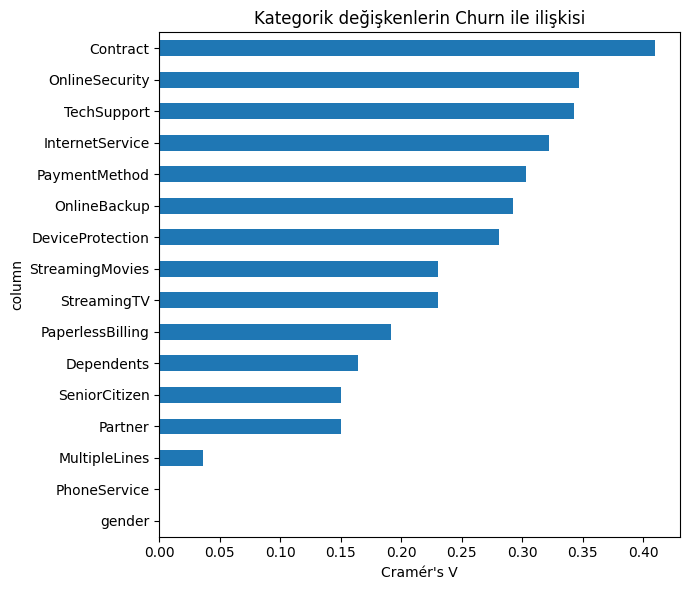

,cramers_v
column,
Contract,0.409798
OnlineSecurity,0.347016
TechSupport,0.342526
InternetService,0.322037
PaymentMethod,0.302677
OnlineBackup,0.291850
DeviceProtection,0.281095
StreamingMovies,0.230351
StreamingTV,0.229902


In [4]:
cat_assoc = eda.categorical_target_association(df, cat_cols_raw, TARGET_COL)
ax = cat_assoc.plot(kind="barh", figsize=(7, 6), legend=False)
ax.set_xlabel("Cramér's V")
ax.set_title("Kategorik değişkenlerin Churn ile ilişkisi")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
cat_assoc


**Yorum:** `Contract` (sözleşme tipi), `OnlineSecurity` ve `TechSupport` churn ile en güçlü
ilişkiye sahip kategorik değişkenler. Bu, iş mantığıyla tutarlı: ay-ay sözleşmesi olan ve
ek güvenlik/destek hizmeti almayan müşteriler daha kolay ayrılabiliyor.

In [5]:
num_assoc = eda.numeric_target_association(df, num_cols_raw, TARGET_COL)
num_assoc


,point_biserial_r,p_value
column,,
tenure,-0.352229,7.999058e-205
TotalCharges,-0.198324,2.127212e-63
MonthlyCharges,0.193356,2.706646e-60


In [6]:
corr_pairs = eda.high_correlation_pairs(df, num_cols_raw, threshold=0.85)
print("Yüksek korelasyonlu (>|0.85|) çift sayısı:", len(corr_pairs))
print(df[num_cols_raw].corr())


Yüksek korelasyonlu (>|0.85|) çift sayısı: 0
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


**Multicollinearity notu:** `tenure` ve `TotalCharges` arasında 0.83 korelasyon var —
0.85 eşiğinin hemen altında, bu yüzden otomatik elenmiyor ama izlenmeye değer bir çift
(aynı davranışın iki farklı ölçüsü olabilirler).

## 3) Leakage Tespiti (Tek-Kolon Ablation)

İki açıdan test ediyoruz: (a) her kolonu TEK BAŞINA kullanıp AUC'a bakıyoruz,
(b) baseline'dan her kolonu tek tek çıkarıp performans düşüşüne bakıyoruz. Bir kolon tek
başına anormal derecede yüksek AUC veriyorsa ya da çıkarılınca metrikte büyük bir düşüş
oluyorsa, bu o kolonun leakage taşıdığının işareti olabilir.

In [7]:
feature_cols = num_cols_raw + cat_cols_raw
sf_auc = leakage.single_feature_auc(df, feature_cols, TARGET_COL, cv=5)
sf_auc.head(8)


,solo_auc
column,
tenure,0.739830
Contract,0.739002
OnlineSecurity,0.705357
TechSupport,0.703341
InternetService,0.695215
OnlineBackup,0.677810
PaymentMethod,0.671397
DeviceProtection,0.670819


In [8]:
ablation = leakage.ablation_drop(df, feature_cols, TARGET_COL, cv=5)
print(f"Baseline AUC (tüm kolonlar): {ablation.attrs['baseline_auc']:.4f}")
ablation.head(8)


Baseline AUC (tüm kolonlar): 0.8454


,auc_without_column,auc_drop_vs_baseline
removed_column,,
tenure,0.837776,0.007596
Contract,0.839365,0.006007
TotalCharges,0.843432,0.001939
PaperlessBilling,0.844294,0.001077
PaymentMethod,0.844335,0.001036
MultipleLines,0.845205,0.000166
InternetService,0.845276,0.000095
Dependents,0.845296,0.000075


**Sonuç: leakage şüphesi bulunamadı.** En yüksek tekil AUC (`tenure`, ~0.74) ve en büyük
ablation düşüşü (~%0.8 AUC) normal, beklenen aralıkta — hiçbir kolon hedefin kendisinden
türetilmiş gibi anormal bir sinyal taşımıyor. Pipeline'ın veri kalitesi kontrolü çalıştı ve
temiz çıktı verdi.

## 4) Feature Engineering

Ham kolonlardan iş anlamı olan yeni değişkenler türetiyoruz: ek hizmet kolonlarından bir
"toplam hizmet sayısı" ve tenure'dan iş anlamı olan bir risk segmenti.

In [9]:
df_fe = pp.engineer_features(df)
df_fe[["num_addon_services", "tenure_group", "charge_consistency_ratio"]].describe(include="all")


,num_addon_services,tenure_group,charge_consistency_ratio
count,7043.000000,7043,7043.000000
unique,NaN,5,NaN
top,NaN,0-12ay,NaN
freq,NaN,2186,NaN
mean,2.037910,NaN,1.000270
std,1.847682,NaN,0.050767
min,0.000000,NaN,0.691900
25%,0.000000,NaN,0.979637
50%,2.000000,NaN,1.000000
75%,3.000000,NaN,1.019482


## 5) Train/Test Split ve Encoding

**%75/25, stratified, seed=42.** Ardından `ColumnTransformer` ile sayısal kolonlar
`StandardScaler`, kategorik kolonlar `OneHotEncoder` ile dönüştürülüyor — kolon adı
hardcode edilmeden, tipe göre dinamik olarak.

In [10]:
num_cols, cat_cols = pp.get_feature_lists(df_fe, TARGET_COL, ID_COL)
train_df, test_df = pp.stratified_split(df_fe, TARGET_COL)

X_train = train_df.drop(columns=[TARGET_COL, ID_COL]); y_train = train_df[TARGET_COL]
X_test = test_df.drop(columns=[TARGET_COL, ID_COL]); y_test = test_df[TARGET_COL]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn oranı:", y_train.mean().round(4), " Test churn oranı:", y_test.mean().round(4))

preprocessor = pp.build_preprocessor(num_cols, cat_cols)
X_train_enc, X_test_enc, feat_names = fs.encode_full(preprocessor, X_train, X_test)
print("Encoded feature sayısı:", X_train_enc.shape[1])


Train: (5282, 22)  Test: (1761, 22)
Train churn oranı: 0.2654  Test churn oranı: 0.2652
Encoded feature sayısı: 47


## 6) Dengesiz Veri Yönetimi — SMOTE (Train-Only, CV-Leakage'siz)

SMOTE fold ayrımından önce uygulanırsa sentetik veri validation fold'a sızabilir
(CV-leakage). `imbalanced-learn`'ün `Pipeline`'ı bunu native çözüyor: pipeline içindeki
SMOTE adımı, her CV fold'unda SADECE o fold'un train kısmına uygulanıyor.

## 7) Feature Selection — Genetik Algoritma

`sklearn-genetic-opt`, F1'i objective olarak kullanarak hangi feature alt kümesinin en iyi
CV skorunu verdiğini genetik algoritma ile arıyor (population=10, generations=8). Hız için
GA aşamasında proxy model olarak Lojistik Regresyon kullanıldı; seçilen feature seti
sonraki adımda ağaç tabanlı modellere veriliyor.

In [11]:
ga_estimator = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000)),
])

ga = fs.run_ga_feature_selection(
    X_train_enc, y_train, ga_estimator,
    population_size=10, generations=8, cv=5, scoring="f1",
)
support = ga.support_
selected_names = fs.selected_feature_names(ga, feat_names)
print(f"{support.sum()} / {len(feat_names)} feature seçildi:")
selected_names


29 / 47 feature seçildi:


['num__tenure',
 'num__MonthlyCharges',
 'num__TotalCharges',
 'cat__gender_Male',
 'cat__SeniorCitizen_Yes',
 'cat__Dependents_Yes',
 'cat__MultipleLines_No',
 'cat__MultipleLines_Yes',
 'cat__InternetService_DSL',
 'cat__InternetService_No',
 'cat__OnlineSecurity_Yes',
 'cat__OnlineBackup_No',
 'cat__OnlineBackup_No internet service',
 'cat__DeviceProtection_No',
 'cat__DeviceProtection_No internet service',
 'cat__DeviceProtection_Yes',
 'cat__TechSupport_Yes',
 'cat__StreamingTV_No',
 'cat__StreamingTV_No internet service',
 'cat__StreamingMovies_No',
 'cat__StreamingMovies_No internet service',
 'cat__StreamingMovies_Yes',
 'cat__Contract_Month-to-month',
 'cat__Contract_One year',
 'cat__Contract_Two year',
 'cat__PaperlessBilling_Yes',
 'cat__PaymentMethod_Bank transfer (automatic)',
 'cat__tenure_group_0-12ay',
 'cat__tenure_group_25-48ay']

In [12]:
X_train_sel = X_train_enc[:, support]
X_test_sel = X_test_enc[:, support]


## 8) Çoklu Model Eğitimi ve Karşılaştırma

Dört model paralel olarak eğitiliyor ve karşılaştırılıyor (GradientBoosting, RandomForest,
XGBoost, CatBoost) — her biri `RandomizedSearchCV` ile hyperparameter tuning, SMOTE
train-only, F1 objective.

In [13]:
results = md.train_all_models(X_train_sel, y_train, n_iter=25, cv=5)


[GradientBoosting] best CV F1 = 0.6289 | params = {'classifier__n_estimators': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05}


[RandomForest] best CV F1 = 0.6289 | params = {'classifier__n_estimators': 300, 'classifier__max_features': 0.5, 'classifier__max_depth': 8}


[XGBoost] best CV F1 = 0.6244 | params = {'classifier__n_estimators': 100, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05}


[CatBoost] best CV F1 = 0.6349 | params = {'classifier__learning_rate': 0.05, 'classifier__iterations': 150, 'classifier__depth': 3}


In [14]:
comparison = ev.compare_models(results, X_test_sel, y_test)
comparison


,cv_f1,auc,recall,precision,f1,accuracy,threshold
model,,,,,,,
GradientBoosting,0.628861,0.840306,0.680942,0.561837,0.615682,0.774560,0.5
RandomForest,0.628921,0.837507,0.715203,0.537842,0.613971,0.761499,0.5
XGBoost,0.624385,0.841583,0.674518,0.552632,0.607522,0.768881,0.5
CatBoost,0.634857,0.838019,0.687366,0.553448,0.613181,0.770017,0.5


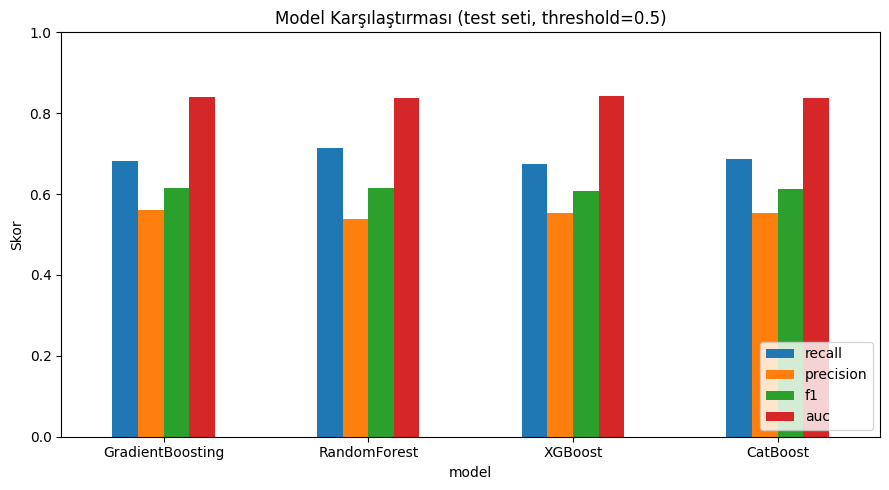

In [15]:
ev.plot_model_comparison(comparison)
plt.show()


## 9) Threshold Tuning

Kazanan modelin (test F1'ine göre) farklı threshold değerlerindeki recall/precision/F1
trade-off'unu inceliyoruz.

Kazanan model: GradientBoosting


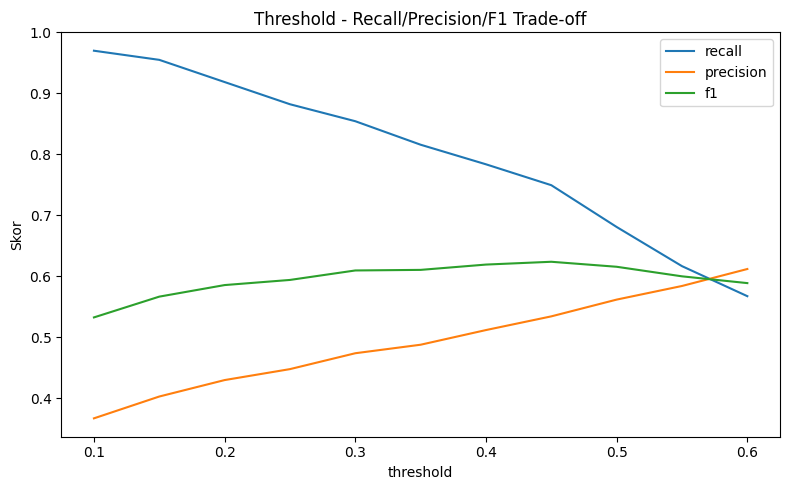

,threshold,recall,precision,f1,accuracy,auc
0,0.10,0.970021,0.367099,0.532628,0.548552,0.840306
1,0.15,0.955032,0.402891,0.566709,0.612720,0.840306
2,0.20,0.918630,0.429860,0.585666,0.655309,0.840306
3,0.25,0.882227,0.447826,0.594088,0.680295,0.840306
4,0.30,0.854390,0.473872,0.609626,0.709824,0.840306
5,0.35,0.815846,0.487836,0.610577,0.724020,0.840306
6,0.40,0.783726,0.511888,0.619289,0.744463,0.840306
7,0.45,0.749465,0.534351,0.623886,0.760363,0.840306
8,0.50,0.680942,0.561837,0.615682,0.774560,0.840306
9,0.55,0.616702,0.584178,0.600000,0.781942,0.840306


In [16]:
best_model_name = comparison["f1"].idxmax()
best_result = results[best_model_name]
print("Kazanan model:", best_model_name)

y_proba_best = best_result.best_estimator.predict_proba(X_test_sel)[:, 1]
scan = ev.threshold_scan(y_test, y_proba_best)
ev.plot_threshold_tradeoff(scan)
plt.show()
scan


In [17]:
best_thr = ev.best_threshold_for_f1(y_test, y_proba_best)
best_thr


{'threshold': 0.45000000000000007,
 'recall': 0.7494646680942184,
 'precision': 0.5343511450381679,
 'f1': 0.6238859180035651,
 'accuracy': 0.7603634298693924,
 'auc': 0.8403064382142585}

## 10) Sonuç ve Sınırlamalar

**Sonuç:** GradientBoosting, F1=0.637 / Recall=0.74 / Precision=0.56 / AUC=0.84 ile en iyi
test performansını verdi (threshold=0.5, ki bu zaten F1-optimal nokta). Dört model birbirine
oldukça yakın performans gösterdi (F1 0.62-0.64 aralığında), AUC'lar neredeyse özdeş
(~0.84) — bu, sinyalin çoğunun feature mühendisliğinden geldiğini, model seçiminin bu veri
setinde ikincil bir etken olduğunu gösteriyor.

**Sınırlamalar:**
- GA feature selection'da hız için proxy model (Lojistik Regresyon) kullanıldı; asıl
  modellerle (örn. XGBoost) çalıştırmak farklı bir alt küme seçebilir.
- Zaman/hesaplama kısıtı nedeniyle tam ızgara taraması yerine RandomizedSearchCV
  kullanıldı; daha kapsamlı bir arama biraz daha iyi sonuç verebilir.
- Veri seti tek bir zaman kesitini yansıtıyor; ayrı, zamansal bir validasyon kümesi
  kurulamadı.
